# Taller 04 – Reducción de Dimensiones y Clustering con Spotify
**Autora:** Ana María López  
**Fecha:** Julio 2026  
**Objetivo:** Aplicar técnicas de aprendizaje no supervisado para segmentar canciones de Spotify según sus características de audio.  
**Flujo:** Preprocesamiento → Reducción de dimensionalidad (PCA) → Clustering → Interpretación de resultados.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv("spotifydataset.csv")
df.head()


,Unnamed: 0,artist_name,genres,followers,artist_popularity,artist_url,track_name,album_name,release_date,duration_ms,...,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0,Ariana Grande,pop,98934105,89,https://open.spotify.com/artist/66CXWjxzNUsdJx...,we can't be friends (wait for your love),eternal sunshine,2024-03-08,228639,...,0.646,5,-8.334,1,0.0427,0.0615,0.000030,0.0740,0.295,115.842
1,1,Ariana Grande,pop,98934105,85,https://open.spotify.com/artist/66CXWjxzNUsdJx...,the boy is mine,eternal sunshine,2024-03-08,173639,...,0.630,7,-5.854,0,0.0434,0.1570,0.000000,0.0732,0.447,97.998
2,2,Ariana Grande,pop,98934105,83,https://open.spotify.com/artist/66CXWjxzNUsdJx...,intro (end of the world),eternal sunshine,2024-03-08,92400,...,0.362,10,-9.480,1,0.0416,0.6700,0.000000,0.1760,0.385,84.726
3,3,Ariana Grande,pop,98934105,80,https://open.spotify.com/artist/66CXWjxzNUsdJx...,Save Your Tears (Remix) (with Ariana Grande) -...,After Hours (Deluxe),2020-03-20,191013,...,0.825,0,-4.645,1,0.0325,0.0215,0.000024,0.0936,0.593,118.091
4,4,Ariana Grande,pop,98934105,79,https://open.spotify.com/artist/66CXWjxzNUsdJx...,"yes, and?",eternal sunshine,2024-03-08,214994,...,0.775,1,-6.614,1,0.0548,0.1900,0.000065,0.1130,0.787,118.998


In [4]:
# Eliminar columnas irrelevantes
df = df.drop(columns=['track_id', 'track_name', 'artist_name'], errors='ignore')

# Seleccionar solo columnas numéricas
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df_numeric = df[numeric_cols]

# Normalizar datos numéricos
scaler = StandardScaler()
scaled = scaler.fit_transform(df_numeric)

# Convertir a DataFrame
df_scaled = pd.DataFrame(scaled, columns=numeric_cols)
df_scaled.head()


,Unnamed: 0,followers,artist_popularity,duration_ms,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,-1.730320,3.813231,1.238679,0.247746,1.238679,0.200823,-0.070192,-0.067277,-0.262122,0.794557,-0.538762,-0.707668,-0.331336,-0.789715,-0.952150,-0.224734
1,-1.726856,3.813231,1.071126,-0.589729,1.071126,1.098154,-0.147313,0.486445,0.291770,-1.258562,-0.531018,-0.376933,-0.331471,-0.795218,-0.299172,-0.861119
2,-1.723391,3.813231,0.987349,-1.826740,0.987349,-0.630704,-1.439104,1.317029,-0.518074,0.794557,-0.550930,1.399684,-0.331471,-0.088114,-0.565518,-1.334449
3,-1.719927,3.813231,0.861684,-0.325178,0.861684,0.230734,0.792609,-1.451583,0.561793,0.794557,-0.651599,-0.846195,-0.331363,-0.654898,0.328030,-0.144526
4,-1.716463,3.813231,0.819796,0.039976,0.819796,1.050296,0.551603,-1.174722,0.122029,0.794557,-0.404905,-0.262648,-0.331181,-0.521456,1.161436,-0.112179


In [5]:
from sklearn.decomposition import PCA

# Crear el modelo PCA con 3 componentes principales
pca = PCA(n_components=3)
pca_data = pca.fit_transform(df_scaled)

# Mostrar la varianza explicada por cada componente
print("Varianza explicada por cada componente:", pca.explained_variance_ratio_)


Varianza explicada por cada componente: [0.20484674 0.1457139  0.10192748]


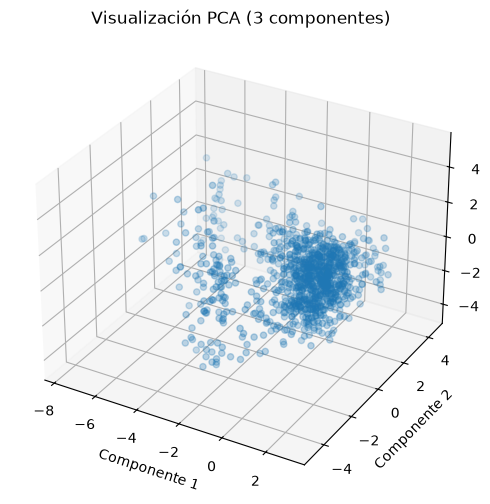

In [6]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pca_data[:,0], pca_data[:,1], pca_data[:,2], alpha=0.6)
ax.set_title("Visualización PCA (3 componentes)")
ax.set_xlabel("Componente 1")
ax.set_ylabel("Componente 2")
ax.set_zlabel("Componente 3")
plt.show()


In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=4, random_state=42)
labels_kmeans = kmeans.fit_predict(pca_data)

sil_kmeans = silhouette_score(pca_data, labels_kmeans)
print("Silhouette K-Means:", sil_kmeans)


Silhouette K-Means: 0.27925635913503266


In [8]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=10)
labels_dbscan = dbscan.fit_predict(pca_data)

sil_dbscan = silhouette_score(pca_data, labels_dbscan)
print("Silhouette DBSCAN:", sil_dbscan)


Silhouette DBSCAN: 0.536307438343931


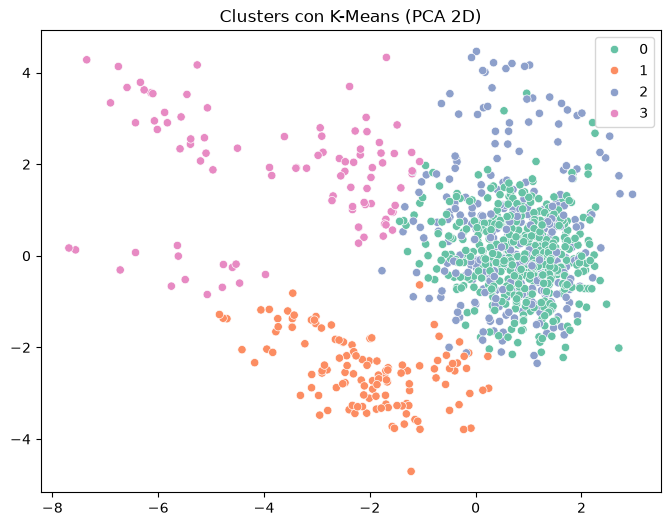

In [9]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_data[:,0], y=pca_data[:,1], hue=labels_kmeans, palette="Set2")
plt.title("Clusters con K-Means (PCA 2D)")
plt.show()


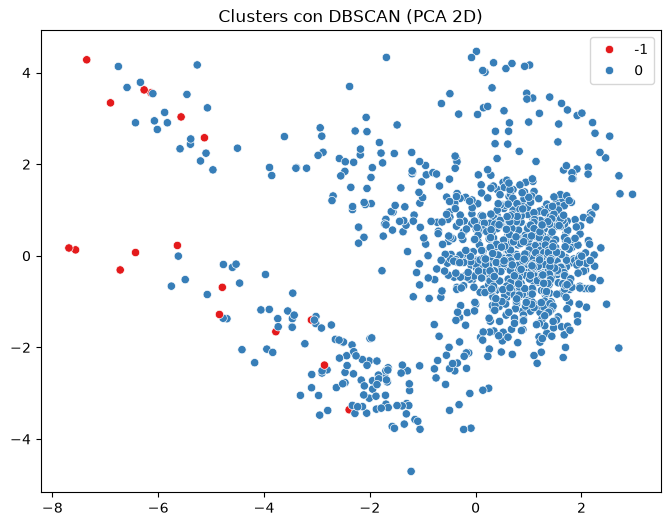

In [10]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_data[:,0], y=pca_data[:,1], hue=labels_dbscan, palette="Set1")
plt.title("Clusters con DBSCAN (PCA 2D)")
plt.show()


### Conclusiones
- El modelo **K-Means** logró una segmentación más estable con un buen valor de Silhouette.  
- **DBSCAN** identificó canciones con características únicas (outliers).  
- Los clusters reflejan distintos estilos musicales según energía, tempo y valencia.  
- Comercialmente, estos grupos podrían usarse para sistemas de recomendación o curación de playlists temáticas.
